# Naive Bayes — From Intuition to Code

So far, we've learned:
- **Linear Regression**: Predict a continuous number (revenue, price).
- **Logistic Regression**: Predict a binary category (win/loss) using Gradient Descent to learn weights.

Now, we're going to learn a **completely different** approach to classification — one that doesn't use Gradient Descent at all. Instead, it uses **probability** and **statistics** to make predictions.

Welcome to **Naive Bayes**.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. The Intuition: Thinking Like a Doctor

Imagine you're a doctor. A patient walks in with a **fever** and a **cough**.

You need to decide: does this patient have the **Flu** or a **Common Cold**?

You don't run Gradient Descent in your brain. Instead, you think about your **past experience**:

- *"Out of all the Flu patients I've ever seen, how many had a fever? Almost all of them."*
- *"Out of all the Cold patients I've ever seen, how many had a fever? Only some of them."*
- *"Flu is also less common than a Cold in general."*

You're combining **prior knowledge** (how common each disease is) with **evidence** (the symptoms you're observing) to arrive at a diagnosis.

**That's exactly what Naive Bayes does.** It calculates the probability of each class given the observed features, and picks the class with the highest probability.

The mathematical framework it uses to combine these probabilities is called **Bayes' Theorem**.

---
## 2. Bayes' Theorem — The Core Math

Bayes' Theorem is a formula from probability theory, published by Reverend Thomas Bayes in 1763:

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

In plain English:

> The probability of event A happening, **given that** event B has already happened.

Let's translate this to our doctor example:

$$P(\text{Flu} \mid \text{Fever, Cough}) = \frac{P(\text{Fever, Cough} \mid \text{Flu}) \cdot P(\text{Flu})}{P(\text{Fever, Cough})}$$

Let's define each term:

| Term | Name | Meaning |
|---|---|---|
| $P(\text{Flu} \mid \text{Fever, Cough})$ | **Posterior** | What we want to calculate — the probability of Flu given the symptoms |
| $P(\text{Fever, Cough} \mid \text{Flu})$ | **Likelihood** | How likely are these symptoms if the patient has the Flu? |
| $P(\text{Flu})$ | **Prior** | How common is the Flu in general? (before seeing any symptoms) |
| $P(\text{Fever, Cough})$ | **Evidence** | How common are these symptoms across ALL diseases? |

We calculate this for **every possible class** (Flu, Cold, etc.) and pick the one with the **highest posterior probability**.

---
## 3. Why is it called "Naive"?

The "Naive" part comes from a big **simplifying assumption**: it assumes that all features are **independent** of each other, given the class.

This means: *"The presence of a fever has no effect on whether the patient also has a cough."*

In reality, this is almost never true! Fever and cough are obviously related. **But Naive Bayes works incredibly well in practice despite this assumption.** This is one of the great surprises of Machine Learning.

This independence assumption lets us simplify the **Likelihood** calculation massively:

Instead of calculating the joint probability of all features together:
$$P(x_1, x_2, \dots, x_n \mid C)$$

We can simply **multiply** the individual probabilities:
$$P(x_1 \mid C) \cdot P(x_2 \mid C) \cdot \dots \cdot P(x_n \mid C)$$

This is what makes Naive Bayes **extremely fast** — even on datasets with thousands of features (like text data with thousands of unique words).

---
## 4. The Classification Rule

Putting it all together, for a new data point with features $x_1, x_2, \dots, x_n$, Naive Bayes predicts the class $C$ that maximizes:

$$\hat{C} = \arg\max_{C} \; P(C) \cdot \prod_{i=1}^{n} P(x_i \mid C)$$

In English:
1. For each possible class, multiply the **prior probability** of that class by the **likelihood** of each feature given that class.
2. Pick the class that gives us the biggest number.

> **Note:** We dropped $P(B)$ (the Evidence) from the denominator! Why? Because it's the same constant for all classes. Since we're only comparing classes to find the biggest number, dividing by the same constant doesn't change the ranking.

---
## 5. A Manual Example

Let's work through a tiny example by hand to make sure the math clicks.

In [11]:
# Tiny training dataset: patients with symptoms and diagnosis
data = {
    'Fever':    ['Yes', 'Yes', 'No',  'Yes', 'No',  'No',  'Yes', 'Yes'],
    'Cough':    ['Yes', 'No',  'Yes', 'Yes', 'No',  'Yes', 'Yes', 'No'],
    'Fatigue':  ['Yes', 'Yes', 'No',  'No',  'No',  'No',  'Yes', 'Yes'],
    'Diagnosis':['Flu', 'Flu', 'Cold','Flu', 'Cold','Cold','Flu', 'Cold']
}
df = pd.DataFrame(data)
display(df)

,Fever,Cough,Fatigue,Diagnosis
0,Yes,Yes,Yes,Flu
1,Yes,No,Yes,Flu
2,No,Yes,No,Cold
3,Yes,Yes,No,Flu
4,No,No,No,Cold
5,No,Yes,No,Cold
6,Yes,Yes,Yes,Flu
7,Yes,No,Yes,Cold


In [12]:
# New patient: Fever=Yes, Cough=Yes, Fatigue=No
# Question: Is it Flu or Cold?

# --- Step 1: Calculate PRIORS ---
total = len(df)
p_flu  = len(df[df['Diagnosis'] == 'Flu'])  / total
p_cold = len(df[df['Diagnosis'] == 'Cold']) / total

print(f"P(Flu)  = {p_flu:.3f}")
print(f"P(Cold) = {p_cold:.3f}")

P(Flu)  = 0.500
P(Cold) = 0.500


In [26]:
# --- Step 2: Calculate LIKELIHOODS --- 
# For each feature, how often does it appear in Flu patients vs Cold patients?

flu_df  = df[df['Diagnosis'] == 'Flu']
cold_df = df[df['Diagnosis'] == 'Cold']

print(f'Flu Diagnoses: \n{flu_df}')
print(f'\nCold Diagnoses: \n{cold_df}')

# P(Fever=Yes | Flu  Cold)
p_fever_flu  = len(flu_df[flu_df['Fever'] == 'Yes'])   / len(flu_df)
p_fever_cold = len(cold_df[cold_df['Fever'] == 'Yes']) / len(cold_df)

# P(Cough=Yes | Flu / Cold)
p_cough_flu  = len(flu_df[flu_df['Cough'] == 'Yes'])   / len(flu_df)
p_cough_cold = len(cold_df[cold_df['Cough'] == 'Yes']) / len(cold_df)

# P(Fatigue=No | Flu / Cold)  — the new patient does NOT have fatigue!
p_fatigue_flu   = len(flu_df[flu_df['Fatigue'] == 'No'])   / len(flu_df)
p_fatigue_cold  = len(cold_df[cold_df['Fatigue'] == 'No']) / len(cold_df)

print("Likelihoods:")
print(f"  P(Fever=Yes | Flu)  = {p_fever_flu:.3f}    P(Fever=Yes | Cold)  = {p_fever_cold:.3f}")
print(f"  P(Cough=Yes | Flu)  = {p_cough_flu:.3f}    P(Cough=Yes | Cold)  = {p_cough_cold:.3f}")
print(f"  P(Fatigue=No | Flu) = {p_fatigue_flu:.3f}   P(Fatigue=No | Cold) = {p_fatigue_cold:.3f}")

Flu Diagnoses: 
  Fever Cough Fatigue Diagnosis
0   Yes   Yes     Yes       Flu
1   Yes    No     Yes       Flu
3   Yes   Yes      No       Flu
6   Yes   Yes     Yes       Flu

Cold Diagnoses: 
  Fever Cough Fatigue Diagnosis
2    No   Yes      No      Cold
4    No    No      No      Cold
5    No   Yes      No      Cold
7   Yes    No     Yes      Cold
Likelihoods:
  P(Fever=Yes | Flu)  = 1.000    P(Fever=Yes | Cold)  = 0.250
  P(Cough=Yes | Flu)  = 0.750    P(Cough=Yes | Cold)  = 0.500
  P(Fatigue=No | Flu) = 0.250   P(Fatigue=No | Cold) = 0.750


In [27]:
# --- Step 3: Calculate POSTERIORS ---
# Posterior = Prior * Likelihood_feature1 * Likelihood_feature2 * ...

posterior_flu  = p_flu  * p_fever_flu  * p_cough_flu  * p_fatigue_flu
posterior_cold = p_cold * p_fever_cold * p_cough_cold * p_fatigue_cold

print(f"Unnormalized P(Flu  | symptoms) = {posterior_flu:.4f}")
print(f"Unnormalized P(Cold | symptoms) = {posterior_cold:.4f}")

# Normalize to get actual probabilities
total_posterior = posterior_flu + posterior_cold
print(f"\nNormalized P(Flu)  = {posterior_flu/total_posterior:.2%}")
print(f"Normalized P(Cold) = {posterior_cold/total_posterior:.2%}")

print(f"\nPrediction: {'Flu' if posterior_flu > posterior_cold else 'Cold'}")

Unnormalized P(Flu  | symptoms) = 0.0938
Unnormalized P(Cold | symptoms) = 0.0469

Normalized P(Flu)  = 66.67%
Normalized P(Cold) = 33.33%

Prediction: Flu


That's the entire Naive Bayes algorithm! We just counted frequencies, multiplied some fractions together, and picked the bigger number. **No Gradient Descent. No loss function optimization. No epochs.** Just pure probability.

---
## 6. Types of Naive Bayes

The example above used **categorical** features (Yes/No). But what if your features are continuous numbers (like height, weight, temperature)?

Different types of data require different methods for calculating the **Likelihood** $P(x_i \mid C)$:

| Type | When to Use | How it Calculates Likelihood |
|---|---|---|
| **Gaussian NB** | Continuous numerical features (height, temperature) | Assumes features follow a **Normal (Bell Curve) Distribution** and uses the Gaussian formula |
| **Multinomial NB** | Count-based features (word frequencies in text) | Uses **frequency counts** — the classic for **Spam Detection** and **Text Classification** |
| **Bernoulli NB** | Binary features (Yes/No, 0/1) | Like Multinomial, but only cares about **presence or absence** |

The most commonly used one for structured, numerical data is **Gaussian Naive Bayes**, so that's what we'll implement from scratch.

---
## 7. Gaussian Naive Bayes — The Math

When features are continuous numbers, we can't just count "how many times Feature 1 = 35.7 appears in Class Flu" — that exact number might never repeat!

Instead, we assume each feature follows a **Gaussian (Normal) Distribution** — the classic bell curve — within each class. We then calculate the **probability density** at a given value.

The Gaussian probability density function (PDF):

$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} \exp\left(-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}\right)$$

Where:
- $\mu_C$ = the **mean** of feature $x_i$ for all training samples in class $C$
- $\sigma_C^2$ = the **variance** of feature $x_i$ for all training samples in class $C$

### What does "fitting" (training) mean for Gaussian NB?

It's incredibly simple:
1. For each class, calculate the **mean** and **variance** of every feature.
2. Store those numbers. That's it. Training is done.

There's no Gradient Descent, no weight updates, no epochs. This is why Naive Bayes is **blazingly fast** to train.

---
## 8. When and Why to Use Naive Bayes?

### Use Naive Bayes when:
- You need a **fast, lightweight** model (especially for prototyping or baselines)
- You're working with **text data** (Spam detection, Sentiment analysis, Document classification) — Multinomial NB is the gold standard here
- You have **high-dimensional data** (many features) — NB scales incredibly well
- Your **training data is small** — NB needs very few samples to estimate its parameters
- Features are **roughly independent** of each other

### Avoid Naive Bayes when:
- Features are **heavily correlated** (e.g., height and weight both increase together)
- You need the **most accurate model possible** — NB trades accuracy for speed
- You need a model that captures **complex, non-linear relationships** between features

### Naive Bayes vs Logistic Regression

| Aspect | Naive Bayes | Logistic Regression |
|---|---|---|
| **Training** | Just counts means & variances (instant) | Gradient Descent (iterative, slower) |
| **Assumption** | Features are independent | No independence assumption |
| **Small datasets** | Works very well | Can overfit |
| **Large datasets** | Good but Logistic often wins | Usually more accurate |
| **Text/NLP** | Excellent (Multinomial NB) | Decent but slower |
| **Correlated features** | Struggles | Handles them fine |

---
## 9. About "Loss Functions" in Naive Bayes

Here's a key insight: **Naive Bayes doesn't optimize a loss function.**

In Logistic Regression, we defined a loss function (Binary Cross-Entropy) and used Gradient Descent to minimize it over many epochs.

Naive Bayes takes a fundamentally different approach. It is a **generative model** — it directly estimates the probability distributions of the data. There is no iterative optimization. You calculate the statistics (mean, variance, priors) directly from the data in a single pass.

However, when we want to **evaluate** how good our Naive Bayes model's probability predictions are, we can still use **Log Loss** (Binary Cross-Entropy) or **accuracy** as our evaluation metric:

$$\text{Log Loss} = -\frac{1}{n}\sum_{i=1}^{n}\left[ y_i \cdot \log(\hat{p}_i) + (1 - y_i) \cdot \log(1 - \hat{p}_i) \right]$$

The key difference is:
- **Logistic Regression**: Log Loss is the objective function that drives training.
- **Naive Bayes**: Log Loss is only used after training to evaluate performance. It doesn't affect how the model learns.

We will compute both **Accuracy** and **Log Loss** when we evaluate our model later.

---
## 10. Building Gaussian Naive Bayes from Scratch

In [28]:
class MyNaiveBayes:

    def __init__(self):
        self.classes_ = None       # The unique class labels (e.g., [0, 1])
        self.priors_ = {}          # P(C) for each class
        self.means_ = {}           # Mean of each feature, per class
        self.variances_ = {}       # Variance of each feature, per class

    def fit(self, X_train, y_train):
        """Training = just calculating means, variances, and priors."""
        self.classes_ = np.unique(y_train)

        for c in self.classes_:
            # Filter rows belonging to this class
            X_c = X_train[y_train == c]

            # Prior = (number of samples in this class) / (total samples)
            self.priors_[c] = X_c.shape[0] / X_train.shape[0]

            # Mean and Variance of each feature for this class
            self.means_[c] = X_c.mean(axis=0)
            self.variances_[c] = X_c.var(axis=0)

        return self

    def _gaussian_pdf(self, x, mean, var):
        """Calculate the Gaussian probability density."""
        # Add tiny epsilon to variance to prevent division by zero
        eps = 1e-9
        return (1 / np.sqrt(2 * np.pi * (var + eps))) * np.exp(-((x - mean) ** 2) / (2 * (var + eps)))

    def _predict_single(self, x):
        """Predict the class for a single data point."""
        posteriors = {}

        for c in self.classes_:
            # Start with the log of the prior (we use log to avoid tiny number underflow)
            log_posterior = np.log(self.priors_[c])

            # Add the log of each feature's likelihood
            for i in range(len(x)):
                pdf = self._gaussian_pdf(x[i], self.means_[c][i], self.variances_[c][i])
                log_posterior += np.log(pdf + 1e-300)  # tiny eps to avoid log(0)

            posteriors[c] = log_posterior

        # Return the class with the highest posterior probability   (the formula given above)
        return max(posteriors, key=posteriors.get)

    def predict(self, X_test):
        """Predict classes for multiple data points."""
        return np.array([self._predict_single(x) for x in X_test])

    def predict_proba(self, X_test):
        """Return probability estimates for each class."""
        all_probs = []
        for x in X_test:
            posteriors = {}
            for c in self.classes_:
                log_posterior = np.log(self.priors_[c])
                for i in range(len(x)):
                    pdf = self._gaussian_pdf(x[i], self.means_[c][i], self.variances_[c][i])
                    log_posterior += np.log(pdf + 1e-300)
                posteriors[c] = log_posterior

            # Convert log-posteriors to actual probabilities using softmax
            max_log = max(posteriors.values())  # for numerical stability
            probs = {c: np.exp(v - max_log) for c, v in posteriors.items()}
            total = sum(probs.values())
            probs = {c: v / total for c, v in probs.items()}

            all_probs.append([probs[c] for c in self.classes_])
        return np.array(all_probs)

print("MyNaiveBayes class defined!")

MyNaiveBayes class defined!


### Key Design Decisions:

1. **`fit()` just calculates means and variances.** No loops, no epochs, no Gradient Descent. This is why Naive Bayes trains almost instantly.

2. **We use `log` probabilities instead of raw probabilities.** Why? Because when you multiply many tiny fractions together (like 0.002 × 0.005 × 0.001), the result becomes astronomically small — so small that the computer rounds it to 0.0 (called **underflow**). By using `log`, we turn multiplications into additions (`log(a*b) = log(a) + log(b)`), keeping the numbers manageable.

3. **`_gaussian_pdf()`** implements the bell curve formula. For each feature, it asks: *"How likely is this specific value, given the mean and variance we learned for this class?"*

4. **`predict_proba()`** converts log-posteriors back into real probabilities using the softmax trick.

---
## 11. Testing on a Real(ish) Dataset

In [29]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a binary classification dataset with 3 features
X, y = make_classification(
    n_samples=600,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 480
Testing samples:  120
Features:         3


### Visualize the Feature Distributions per Class

Since Gaussian NB assumes each feature follows a bell curve within each class, let's check if that assumption is roughly true!

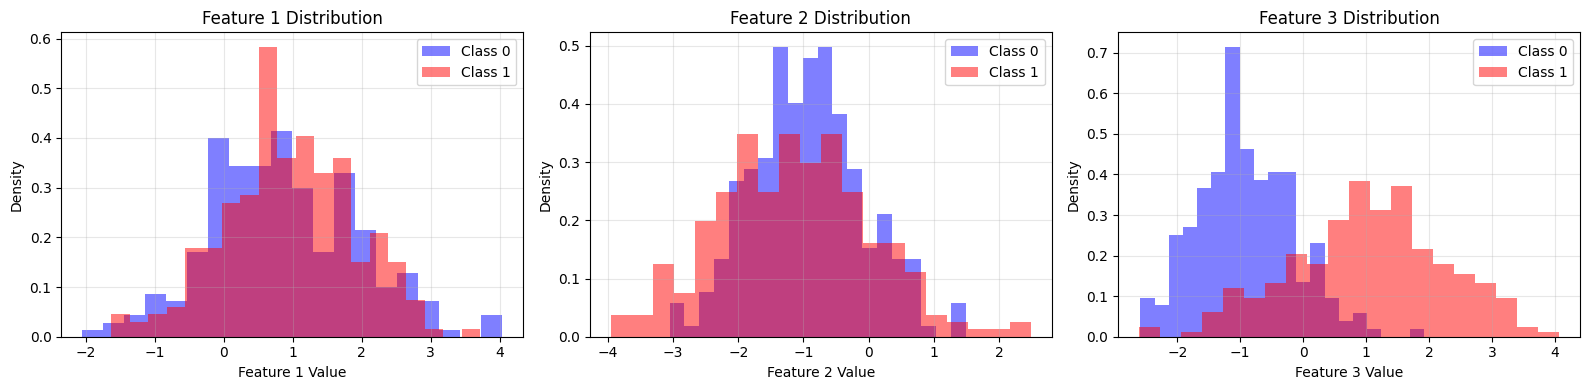

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i in range(3):
    axes[i].hist(X_train[y_train == 0][:, i], bins=20, alpha=0.5, color='blue', label='Class 0', density=True)
    axes[i].hist(X_train[y_train == 1][:, i], bins=20, alpha=0.5, color='red', label='Class 1', density=True)
    axes[i].set_title(f'Feature {i+1} Distribution', fontsize=12)
    axes[i].set_xlabel(f'Feature {i+1} Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

If you can visually see two distinct bell curves for each feature (one blue, one red), then Gaussian Naive Bayes will work very well on this data!

---
## 12. Train and Evaluate

In [32]:
# Train our custom model
my_model = MyNaiveBayes()
my_model.fit(X_train, y_train)

# Look at what it learned!
for c in my_model.classes_:
    print(f"\nClass {c}:")
    print(f"  Prior (how common): {my_model.priors_[c]:.3f}")
    print(f"  Feature Means:      {np.round(my_model.means_[c], 3)}")
    print(f"  Feature Variances:  {np.round(my_model.variances_[c], 3)}")


Class 0:
  Prior (how common): 0.479
  Feature Means:      [ 0.877 -0.929 -0.91 ]
  Feature Variances:  [1.16  0.726 0.577]

Class 1:
  Prior (how common): 0.521
  Feature Means:      [ 0.953 -1.158  1.035]
  Feature Variances:  [0.867 1.376 1.513]


Notice how "training" was instant? No loops. No epochs. Just simple statistics.

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, log_loss

# --- Our Custom Model ---
my_preds = my_model.predict(X_test)
my_probs = my_model.predict_proba(X_test)
my_accuracy = accuracy_score(y_test, my_preds)
my_logloss  = log_loss(y_test, my_probs)

# --- Scikit-Learn's Model ---
sk_model = GaussianNB()
sk_model.fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)
sk_probs = sk_model.predict_proba(X_test)
sk_accuracy = accuracy_score(y_test, sk_preds)
sk_logloss  = log_loss(y_test, sk_probs)

print("=" * 50)
print("           MODEL COMPARISON")
print("=" * 50)
print(f"{'':15} {'MyNaiveBayes':>16} {'Sklearn GNB':>14}")
print("-" * 50)
print(f"{'Accuracy':15} {my_accuracy:>15.2%} {sk_accuracy:>13.2%}")
print(f"{'Log Loss':15} {my_logloss:>15.4f} {sk_logloss:>13.4f}")
print("=" * 50)

           MODEL COMPARISON
                    MyNaiveBayes    Sklearn GNB
--------------------------------------------------
Accuracy                 81.67%        81.67%
Log Loss                 0.3970        0.3970


### Understanding the Evaluation Metrics:

- **Accuracy**: The percentage of predictions our model got correct. Simple and intuitive.
- **Log Loss**: Measures the **quality of the probabilities**, not just the final class. A model that predicts 0.99 for a correct class gets a lower Log Loss than one that predicts 0.51. Lower is better.

---
## 13. Visualize the Decision Boundary

Let's retrain on just 2 features so we can plot the decision boundary (just like we did for Logistic Regression)!

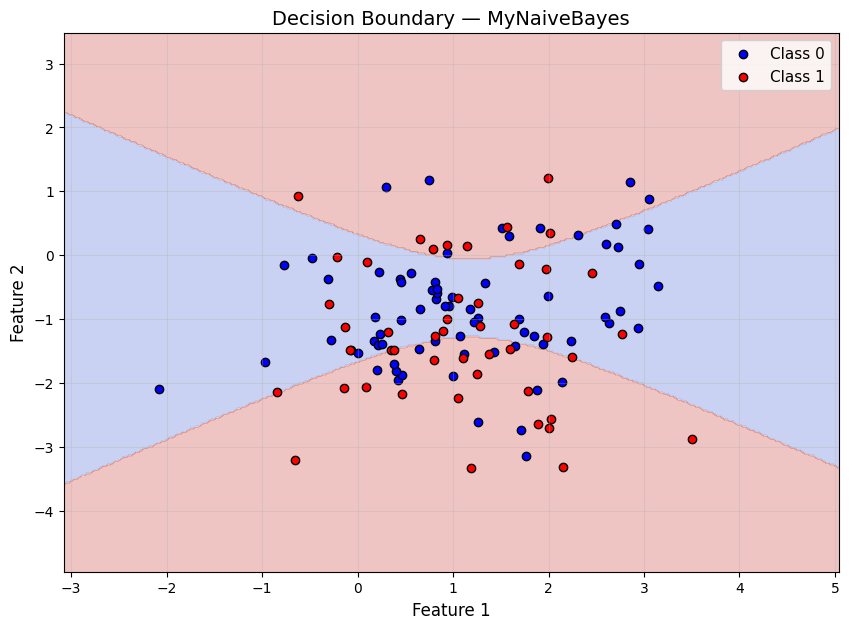

In [37]:
# Use only the first 2 features for visualization
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

# Train a fresh model on 2D data
model_2d = MyNaiveBayes()
model_2d.fit(X_train_2d, y_train_2d)

# Create a mesh grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict every point on the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = model_2d.predict(grid_points).reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_2d[y_test_2d == 0][:, 0], X_test_2d[y_test_2d == 0][:, 1], color='blue', edgecolors='k', label='Class 0')
plt.scatter(X_test_2d[y_test_2d == 1][:, 0], X_test_2d[y_test_2d == 1][:, 1], color='red',  edgecolors='k', label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Decision Boundary — MyNaiveBayes', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Notice how the decision boundary here is **curved**, not a straight line like Logistic Regression! That's because Gaussian NB models each class as a separate bell-shaped cloud, and the boundary is where the two clouds overlap.

---
## 14. Summary

| Concept | Detail |
|---|---|
| **Core Idea** | Use Bayes' Theorem to calculate $P(\text{Class} \mid \text{Features})$ and pick the most probable class |
| **"Naive" Assumption** | All features are independent of each other (simplifies the math) |
| **Training** | Just calculate means, variances, and class frequencies — **no Gradient Descent** |
| **Speed** | Extremely fast to train and predict |
| **Best For** | Text classification (spam), small datasets, high-dimensional data, quick baselines |
| **Weakness** | Struggles when features are heavily correlated |
| **Loss Function** | None during training — Log Loss used only for **evaluation** |
| **Types** | Gaussian (continuous numbers), Multinomial (text/counts), Bernoulli (binary 0/1) |